In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_pickle('classification_4t_scratch.pkl')
df = df.loc[~df.index.get_level_values(0).str.startswith('ResNet'), df.columns.str.endswith('_auc')]
df

ImageWoof_auc  PathMNIST_auc  DermaMNIST_auc  \
Token Mixer Kernel Size                                                 
pooling     3                   0.9495         0.9758          0.8883   
            5                   0.9517         0.9799          0.8911   
            7                   0.9539         0.9829          0.8795   
conv        3                   0.9483         0.9834          0.8675   
            5                   0.9353         0.9878          0.8855   
            7                   0.9235         0.9887          0.8628   
sep_conv    3                   0.9534         0.9803          0.8867   
            5                   0.9412         0.9821          0.8746   
            7                   0.9341         0.9798          0.8681   
locAttn     3                   0.9152         0.9701          0.8869   
            5                   0.9104         0.9726          0.8538   
            7                   0.9014         0.9782          0.8458   
fullAttn    -                   0.8885         0.9802          0.9174   
identity    1                   0.9575         0.9756          0.8784   

                         PneumoniaMNIST_auc  OrganSMNIST_auc  
Token Mixer Kernel Size                                       
pooling     3                        0.9921           0.9617  
            5                        0.9832           0.9375  
            7                        0.9814           0.9420  
conv        3                        0.9761           0.9534  
            5                        0.9807           0.9475  
            7                        0.9925           0.9503  
sep_conv    3                        0.9886           0.9535  
            5                        0.9863           0.9410  
            7                        0.9878           0.9440  
locAttn     3                        0.9739           0.9384  
            5                        0.9780           0.9274  
            7                        0.9803           0.9326  
fullAttn    -                        0.9493           0.9679  
identity    1                        0.9883           0.9626

In [2]:
df_long = df.copy()
# df_long.insert(0, 'avg', df_long.mean(axis=1))
df_long = df_long.reset_index().melt(id_vars=["Token Mixer", "Kernel Size"], var_name="dataset", value_name="auc")
df_long.loc[df_long['Kernel Size'].isin(['1', '-']), 'Kernel Size'] = '~'
df_long

,Token Mixer,Kernel Size,dataset,auc
0,pooling,3,ImageWoof_auc,0.9495
1,pooling,5,ImageWoof_auc,0.9517
2,pooling,7,ImageWoof_auc,0.9539
3,conv,3,ImageWoof_auc,0.9483
4,conv,5,ImageWoof_auc,0.9353
...,...,...,...,...
65,locAttn,3,OrganSMNIST_auc,0.9384
66,locAttn,5,OrganSMNIST_auc,0.9274
67,locAttn,7,OrganSMNIST_auc,0.9326
68,fullAttn,~,OrganSMNIST_auc,0.9679


In [3]:
df_long['Kernel Size'].isin(['1', '-'])

0     False
1     False
2     False
3     False
4     False
      ...  
65    False
66    False
67    False
68    False
69    False
Name: Kernel Size, Length: 70, dtype: bool

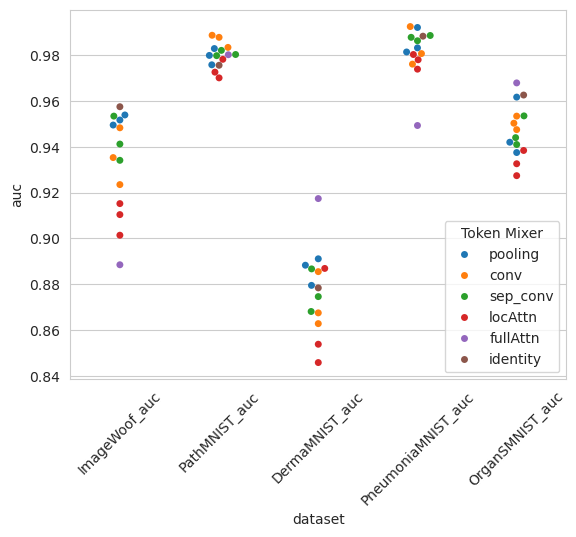

In [4]:
sns.swarmplot(df_long, x='dataset', y='auc', hue='Token Mixer', )
plt.xticks(rotation=45);

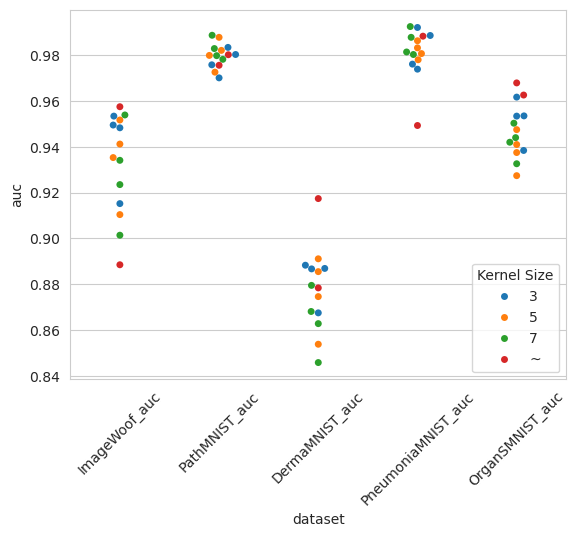

In [5]:
sns.swarmplot(df_long, x='dataset', y='auc', hue='Kernel Size')
plt.xticks(rotation=45);

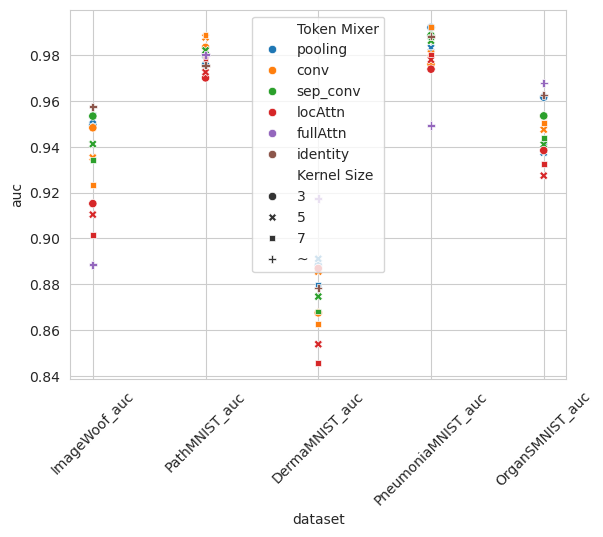

In [6]:
sns.scatterplot(df_long, x='dataset', y='auc', hue='Token Mixer', style='Kernel Size')
plt.xticks(rotation=45);

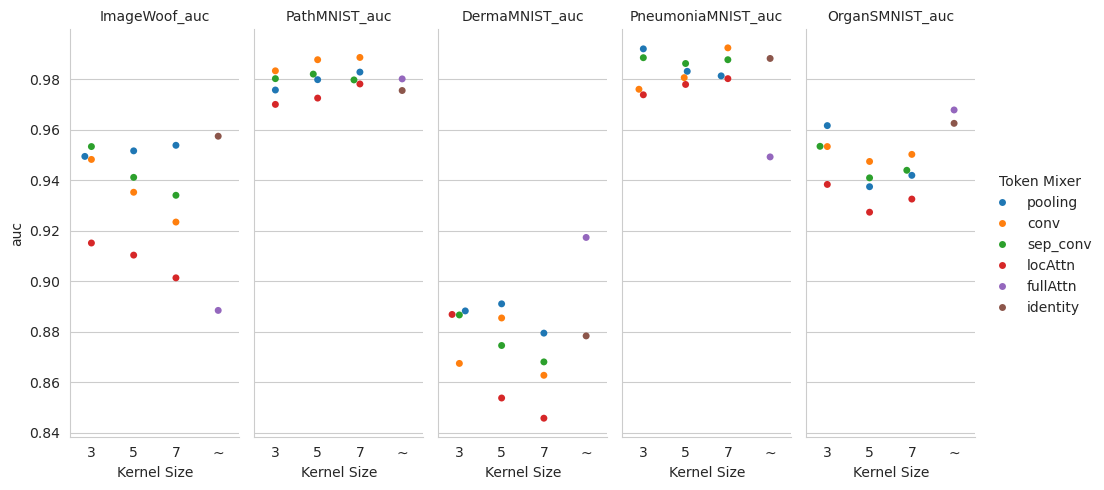

In [7]:
g = sns.catplot(df_long, y='auc', x='Kernel Size', hue='Token Mixer', col='dataset', kind='swarm', aspect=0.4)
g.set_titles(col_template="{col_name}")

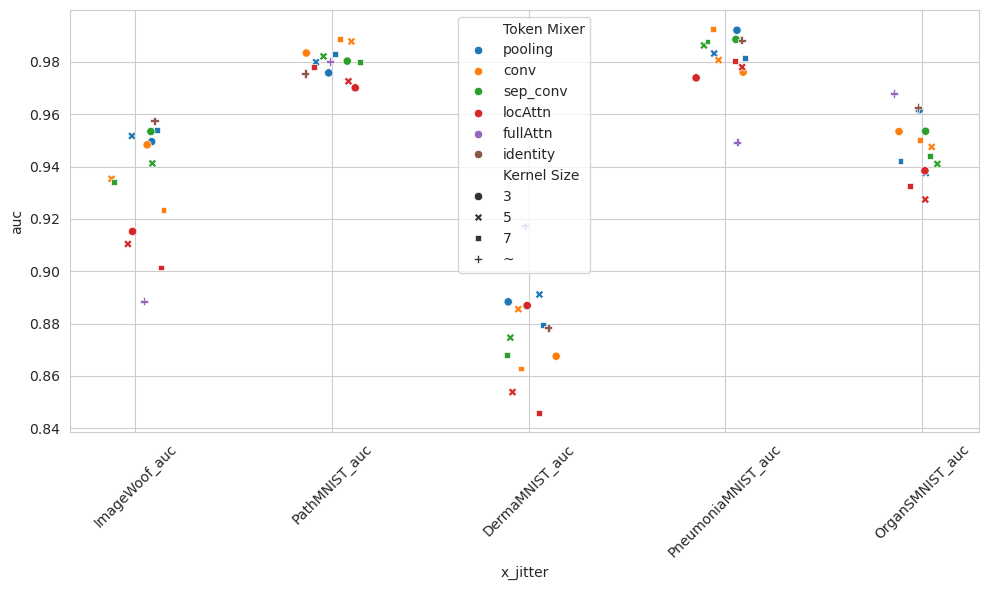

In [8]:
import numpy as np

# make a copy so we don't mess original df_long
df_jitter = df_long.copy()

# assign numeric x positions per dataset
dataset_codes = {d: i for i, d in enumerate(df_jitter["dataset"].unique())}
df_jitter["x_pos"] = df_jitter["dataset"].map(dataset_codes)

# add small uniform noise (jitter) to x positions
rng = np.random.default_rng(42)   # for reproducibility
df_jitter["x_jitter"] = df_jitter["x_pos"] + rng.uniform(-0.15, 0.15, len(df_jitter))

# now plot using the jittered x instead of the categorical string
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_jitter,
    x="x_jitter",
    y="auc",
    hue="Token Mixer",
    style="Kernel Size"
)

# relabel x-axis back to dataset names
plt.xticks(list(dataset_codes.values()), list(dataset_codes.keys()), rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df_wide = df.copy()
df_wide.insert(0, 'avg', df_wide.mean(1))
df_wide

avg  ImageWoof_auc  PathMNIST_auc  \
Token Mixer Kernel Size                                          
pooling     3            0.95348         0.9495         0.9758   
            5            0.94868         0.9517         0.9799   
            7            0.94794         0.9539         0.9829   
conv        3            0.94574         0.9483         0.9834   
            5            0.94736         0.9353         0.9878   
            7            0.94356         0.9235         0.9887   
sep_conv    3            0.95250         0.9534         0.9803   
            5            0.94504         0.9412         0.9821   
            7            0.94276         0.9341         0.9798   
locAttn     3            0.93690         0.9152         0.9701   
            5            0.92844         0.9104         0.9726   
            7            0.92766         0.9014         0.9782   
fullAttn    -            0.94066         0.8885         0.9802   
identity    1            0.95248         0.9575         0.9756   

                         DermaMNIST_auc  PneumoniaMNIST_auc  OrganSMNIST_auc  
Token Mixer Kernel Size                                                       
pooling     3                    0.8883              0.9921           0.9617  
            5                    0.8911              0.9832           0.9375  
            7                    0.8795              0.9814           0.9420  
conv        3                    0.8675              0.9761           0.9534  
            5                    0.8855              0.9807           0.9475  
            7                    0.8628              0.9925           0.9503  
sep_conv    3                    0.8867              0.9886           0.9535  
            5                    0.8746              0.9863           0.9410  
            7                    0.8681              0.9878           0.9440  
locAttn     3                    0.8869              0.9739           0.9384  
            5                    0.8538              0.9780           0.9274  
            7                    0.8458              0.9803           0.9326  
fullAttn    -                    0.9174              0.9493           0.9679  
identity    1                    0.8784              0.9883           0.9626

In [10]:
df_wide_id = df_wide.copy().reset_index()
df_wide_id.insert(0, 'id', df_wide_id['Token Mixer'] + df_wide_id['Kernel Size'])
df_wide_id.drop(['Token Mixer', 'Kernel Size'], axis=1, inplace=True)

df_wide_id

,id,avg,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
0,pooling3,0.95348,0.9495,0.9758,0.8883,0.9921,0.9617
1,pooling5,0.94868,0.9517,0.9799,0.8911,0.9832,0.9375
2,pooling7,0.94794,0.9539,0.9829,0.8795,0.9814,0.9420
3,conv3,0.94574,0.9483,0.9834,0.8675,0.9761,0.9534
4,conv5,0.94736,0.9353,0.9878,0.8855,0.9807,0.9475
5,conv7,0.94356,0.9235,0.9887,0.8628,0.9925,0.9503
6,sep_conv3,0.95250,0.9534,0.9803,0.8867,0.9886,0.9535
7,sep_conv5,0.94504,0.9412,0.9821,0.8746,0.9863,0.9410
8,sep_conv7,0.94276,0.9341,0.9798,0.8681,0.9878,0.9440
9,locAttn3,0.93690,0.9152,0.9701,0.8869,0.9739,0.9384


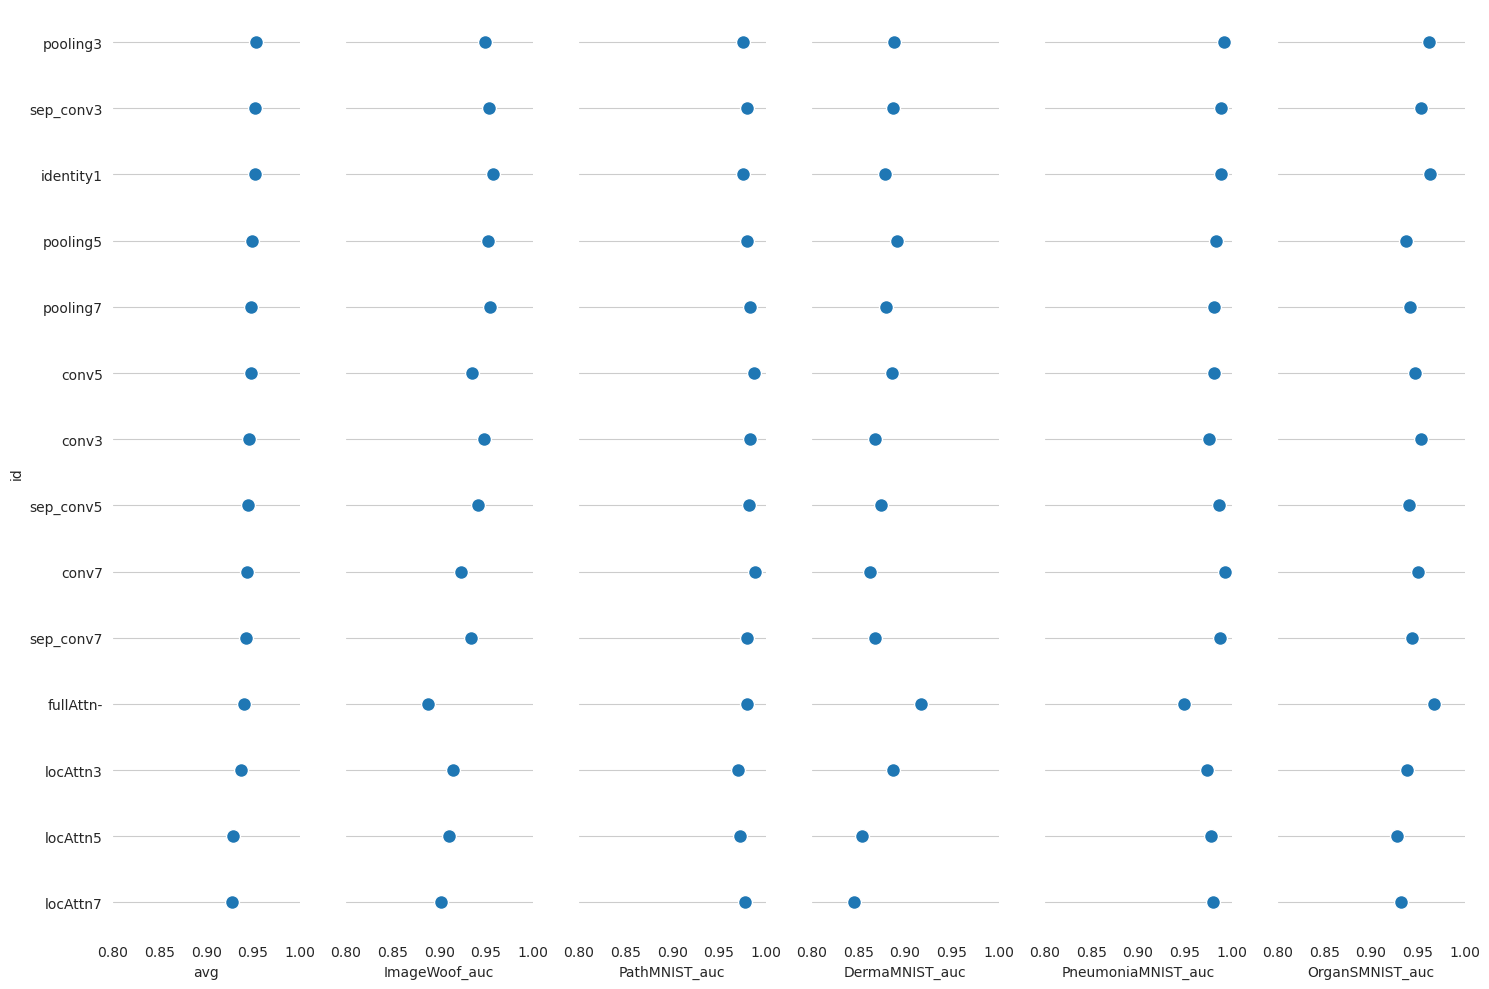

In [11]:
g = sns.PairGrid(df_wide_id.sort_values("avg", ascending=False), x_vars=df_wide_id.columns[1:], y_vars='id', height=10, aspect=.25)
# Draw a dot plot using the stripplot function
g.map(sns.stripplot, size=10, orient="h", jitter=False,
      palette="flare_r", linewidth=1, edgecolor="w")
# Use the same x axis limits on all columns and add better labels
g.set(xlim=(0.8, 1))

for ax in g.axes.flat:
    # Make the grid horizontal instead of vertical
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)

sns.despine(left=True, bottom=True)
plt.tight_layout()


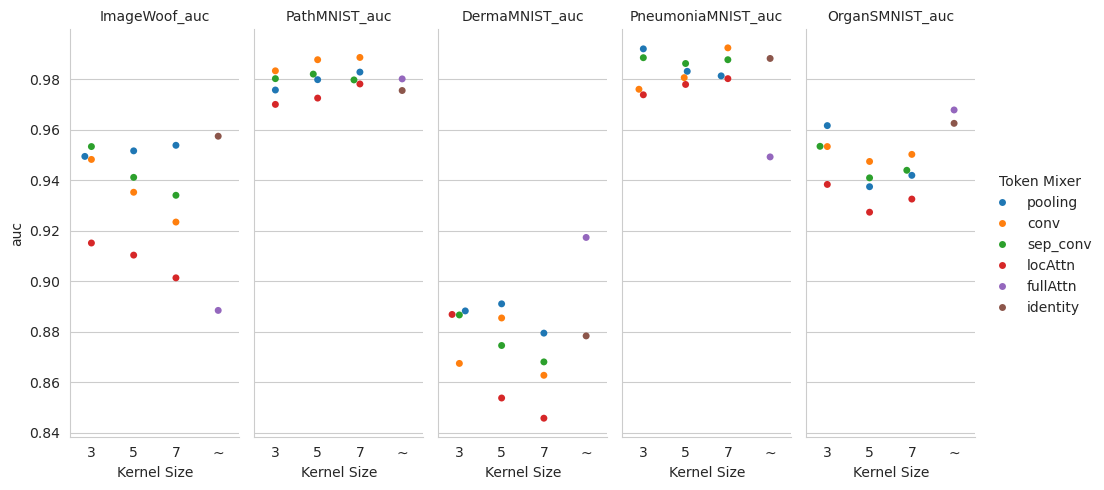

In [12]:
g = sns.catplot(df_long, y='auc', x='Kernel Size', hue='Token Mixer', col='dataset', kind='swarm', aspect=0.4)
g.set_titles(col_template="{col_name}")

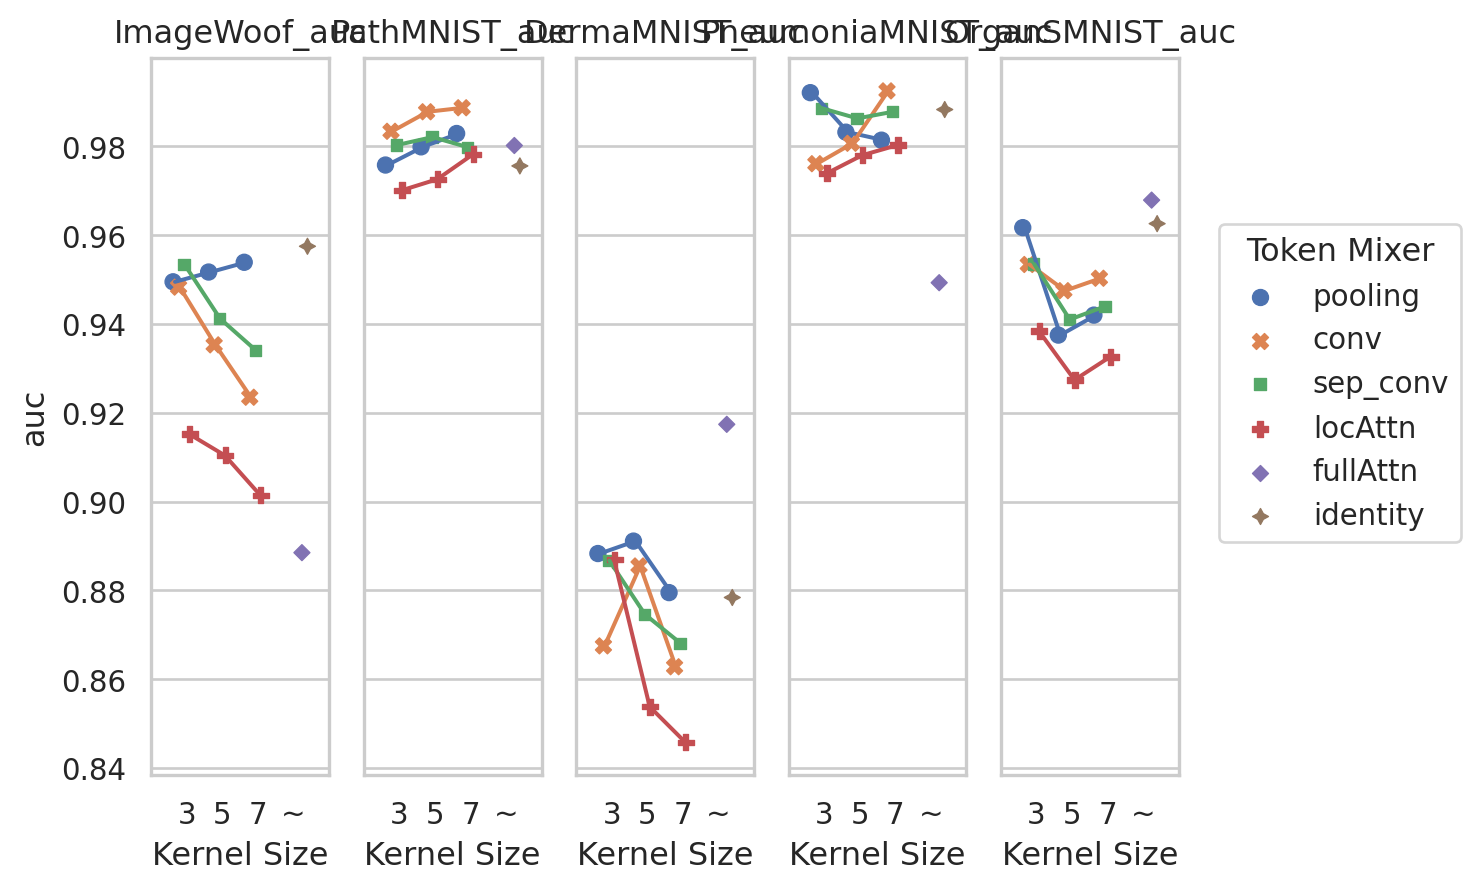

In [39]:
from seaborn import objects as so

(
    so.Plot(df_long, x="Kernel Size", y="auc", color="Token Mixer")
    .facet(col="dataset")
    .theme(sns.axes_style("whitegrid"))
    .add(so.Line(), so.Dodge(), legend=False)
    .add(so.Dot(), so.Dodge(), marker='Token Mixer')
    .limit(x=(-1, 4))
    .layout(engine='tight')
)

AttributeError: PathCollection.set() got an unexpected keyword argument 'dodge'

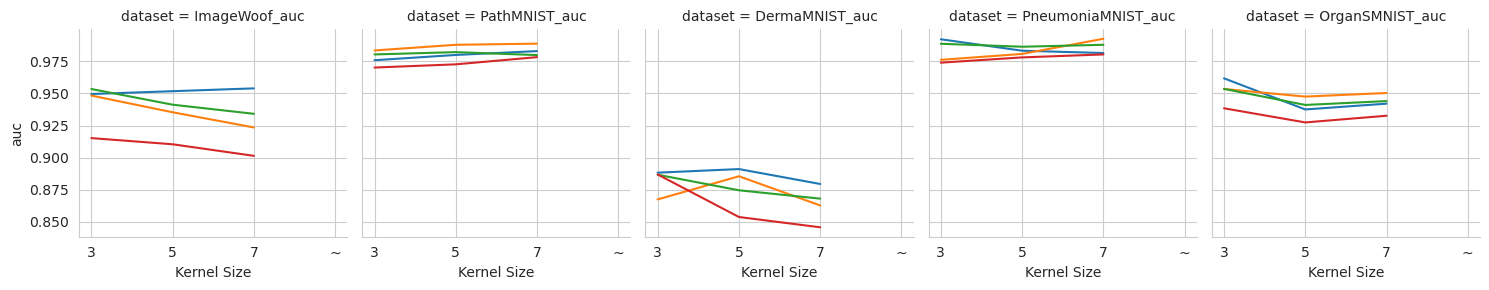

In [27]:
g = sns.FacetGrid(df_long, col='dataset')
g.map_dataframe(sns.lineplot, x='Kernel Size', y='auc', hue='Token Mixer')
g.map_dataframe(sns.scatterplot, x='Kernel Size', y='auc', hue='Token Mixer', dodge=True)